<>:21: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:21: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
/tmp/ipykernel_152989/2430651656.py:21: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  plt.title('Perfil Radial da Frequência de Rabi na Cavidade (Modo $\mathrm{TE}_{011}$)')


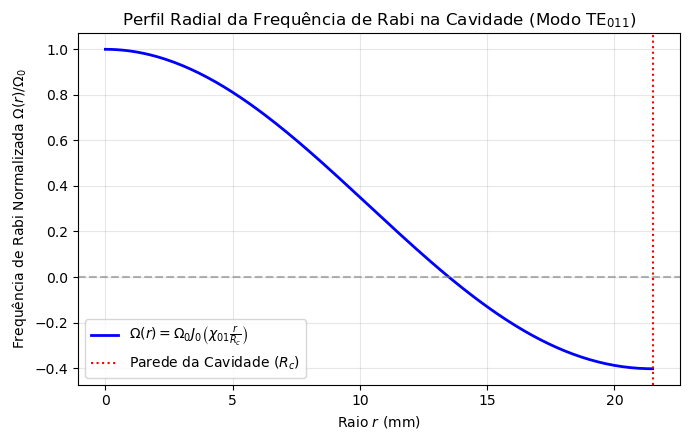

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.special import j0, j1

# --- Parâmetros Físicos da Cavidade ---
Rc = 0.0215  # Raio da cavidade (21.5 mm)
H = 0.025  # Altura da cavidade (25 mm)
chi01 = 3.8317  # Primeira raiz de J_1(x) = 0 (condição do modo TE011)

# ==============================================================================
# 1. PERFIL RADIAL 1D: Frequência de Rabi Normalizada \Omega(r) / \Omega_0
# ==============================================================================
r_1d = np.linspace(0, Rc, 200)
Omega_r = j0(chi01 * r_1d / Rc)

plt.figure(figsize=(7, 4.5))
plt.plot(r_1d * 1000, Omega_r, 'b-', lw=2, label=r'$\Omega(r) = \Omega_0 J_0\left(\chi_{01} \frac{r}{R_c}\right)$')
plt.axhline(0, color='gray', linestyle='--', alpha=0.6)
plt.axvline(Rc * 1000, color='red', linestyle=':', label='Parede da Cavidade ($R_c$)')

plt.title('Perfil Radial da Frequência de Rabi na Cavidade (Modo $\mathrm{TE}_{011}$)')
plt.xlabel('Raio $r$ (mm)')
plt.ylabel(r'Frequência de Rabi Normalizada $\Omega(r) / \Omega_0$')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()



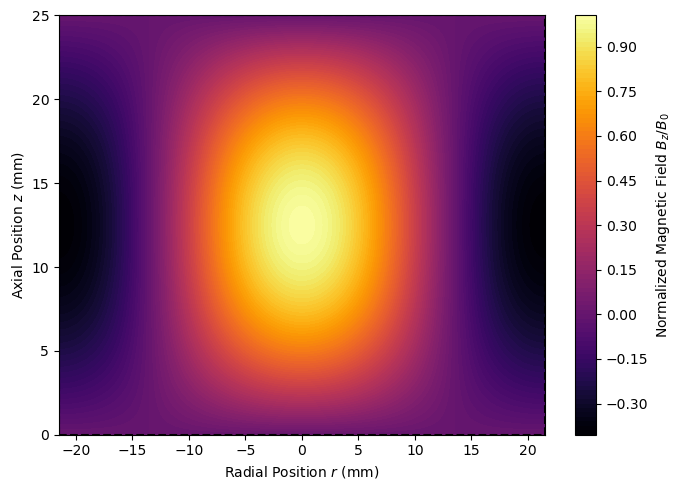

In [4]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.special import j0, j1


# --- Parâmetros Físicos da Cavidade ---
Rc = 0.0215  # Raio da cavidade (21.5 mm)
H = 0.025  # Altura da cavidade (25 mm)
chi01 = 3.8317  # Primeira raiz de J_1(x) = 0 (condição do modo TE011)

# ==============================================================================
# 2. MAPA DE CALOR 2D: Campo Magnético Longitudinal B_z(r, z)
# ==============================================================================
r_2d = np.linspace(-Rc, Rc, 1000)
z_2d = np.linspace(0, H, 1000)
R, Z = np.meshgrid(r_2d, z_2d)

# Campo Bz(r, z) normalizado
Bz = j0(chi01 * np.abs(R) / Rc) * np.sin(np.pi * Z / H)

plt.figure(figsize=(7, 5))
contour = plt.contourf(
    R * 1000,
    Z * 1000,
    Bz,
    levels=100,
    cmap='inferno',  # Gradiente azul-púrpura
)
cbar = plt.colorbar(contour)
cbar.set_label(r'Normalized Magnetic Field $B_z / B_0$')

# Desenhar contorno da cavidade
plt.axvline(-Rc * 1000, color='black', lw=1.5, ls='--')
plt.axvline(Rc * 1000, color='black', lw=1.5, ls='--')
plt.axhline(0, color='black', lw=1.5, ls='--')
plt.axhline(H * 1000, color='black', lw=1.5, ls='--')

plt.xlabel('Radial Position $r$ (mm)')
plt.ylabel('Axial Position $z$ (mm)')
plt.grid(False)
plt.tight_layout()
plt.savefig('perfil_cav(eng).png', dpi=300)
plt.show()


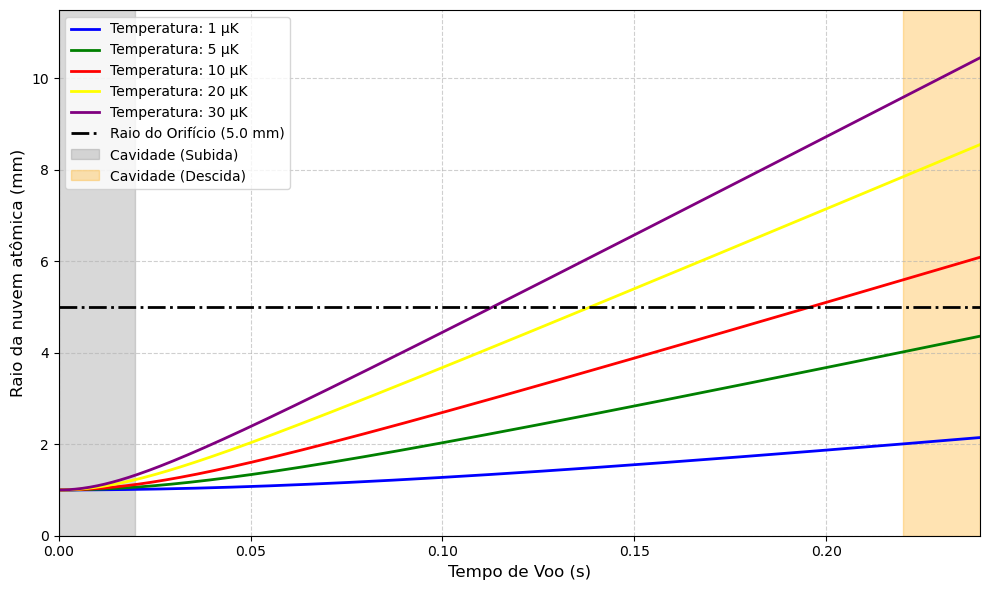

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Parâmetros Físicos e do Experimento
# ---------------------------------------------------------
k_B = 1.380649e-23     # Constante de Boltzmann (J/K)
m_cs = 2.20694650e-25  # Massa do Césio-133 (kg)

T = 0.2               # Tempo de voo livre (s)
t_cav = 2e-2         # Tempo de interação com a cavidade (s)
tempo_total = T + 2 * t_cav

# Parâmetros geométricos (em mm)
R0_mm = 1.0            # Raio inicial da nuvem na MOT
r_orificio_mm = 5.0    # Raio do orifício da cavidade (AJUSTE CONFORME SEU SETUP)

# Temperaturas avaliadas
temperaturas = [1e-6, 5e-6, 10e-6, 20e-6, 30e-6] 
labels = ['1 µK', '5 µK', '10 µK', '20 µK', '30 µK']
cores = ['blue', 'green', 'red', 'yellow', 'purple']

# Eixo de tempo
tempo = np.linspace(0, tempo_total, 500)

plt.figure(figsize=(10, 6))

# ---------------------------------------------------------
# Cálculo e Plotagem do Raio da Nuvem
# ---------------------------------------------------------
for temp, label, cor in zip(temperaturas, labels, cores):
    v_rms = np.sqrt(k_B * temp / m_cs)
    dispersao_mm = (v_rms * tempo) * 1000 
    raio_nuvem_mm = np.sqrt(R0_mm**2 + dispersao_mm**2)
    
    plt.plot(tempo, raio_nuvem_mm, label=f'Temperatura: {label}', color=cor, linewidth=2)

# ---------------------------------------------------------
# Marcações Espaciais (Cavidades e Orifício)
# ---------------------------------------------------------
# Marcação do orifício de entrada/saída
plt.axhline(y=r_orificio_mm, color='black', linestyle='-.', linewidth=2, label=f'Raio do Orifício ({r_orificio_mm} mm)')

# 1º Pulso: Subida
plt.axvspan(0, t_cav, color='gray', alpha=0.3, label='Cavidade (Subida)')

# 2º Pulso: Descida
plt.axvspan(T + t_cav, tempo_total, color='orange', alpha=0.3, label='Cavidade (Descida)')

# ---------------------------------------------------------
# Formatação do Gráfico
# ---------------------------------------------------------
plt.xlabel('Tempo de Voo (s)', fontsize=12)
plt.ylabel(r'Raio da nuvem atômica (mm)', fontsize=12)
plt.xlim(0, tempo_total)
plt.ylim(0, max(r_orificio_mm * 1.5, np.max(raio_nuvem_mm) * 1.1)) # Escala dinâmica para focar na zona de corte
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper left')
plt.tight_layout()

# Exibir o gráfico
plt.savefig("exp_raio.png", dpi=300)
plt.show()